In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
import warnings
import pickle as pkl
import os
warnings.simplefilter("ignore")

In [4]:
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)

In [5]:
from mtu_plots import graph_metrics_models_and_mtu

In [6]:
model_keys = [
    "ideal",
    "content_5",
    "content_10",
    "pop",
    "mf",
    "sf",
    "random"
]

metric_list = [
    "interaction_history",
    "decisions",
    "utility_history",
    "trait_history",
    "rank_history",
    ]

feed_names = [
    "rand_feed",
    "pop_feed",
    "trend_feed",
    "new_feed",
    "social_feed",
    "ideal_feed",
    "any_feed",
    ]

In [7]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})
plotting_sigma = 0.1
mult_sd = 0.25

rs_colors = {
    'content_5' : 'tab:green',
    'content_10' : 'tab:orange',
    'pop' : 'tab:red',
    'sf' : 'tab:brown',
    'mf' : 'tab:purple',
    'ideal' : 'tab:blue',
    'random' : 'tab:pink'
}

# readable legend keys
model_to_readable = {
    "ideal": "Ideal",
    "content_5": "Content Filtering 5 Tags",
    "content_10": "Content Filtering 10 Tags",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

feed_names_to_readable = {
    "rand_feed": "Rand",
    "pop_feed": "Pop",
    "trend_feed": "Trend",
    "new_feed": "New",
    "social_feed": "Social",
    "ideal_feed": "Ideal",
    "any_feed": "Any",
}

In [8]:
results_file = "/home/salveal/data/salveal/results11"
inpi = 40
all_folder_paths = {feed_folder_path : [results_file + "/" + feed_folder_path + "/r" + str(i) for i in range(6)]
                    for feed_folder_path in feed_names}
all_results_to_readable = {feed: {all_folder_paths[feed][i]: (("RS: "*int(i==0))+str(100-20*i))
                                                                 +"%\n"
                                                                 +(((feed_names_to_readable[feed] + ": ")*int(i==0))+str(20*i))
                                                                 +"%" 
                                for i in range(6)} 
                           for feed in feed_names}
all_results_to_readable["social_feed"][all_folder_paths["social_feed"][5]] = "1%\n99%"

In [9]:
all_final_results = dict()
all_item_attrs = dict()
for feed, folder_paths in all_folder_paths.items():
    final_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for folder_path in folder_paths:
        filepath = os.path.join(folder_path, "sim_results.pkl")
        results = pkl.load(open(filepath, "rb"))
        for metric_name, v in results.items():
            for model_name, metric_vals in v.items():
                final_results[metric_name][model_name][folder_path] += np.array(metric_vals).tolist()
    all_final_results[feed] = final_results
    all_item_attrs[feed] = np.array(final_results['item_attrs']['all'][folder_paths[0]])

In [10]:
all_interactions = dict()
all_user_iter_attrs_ideals = dict()
for feed, folder_paths in all_folder_paths.items():
    interactions = dict()
    for mo in model_keys:
        interactions[mo] = dict()
        folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
        for fo in folder_to_inspect:
            interactions[mo][fo] = np.array(all_final_results[feed]['interaction_history'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['interaction_history'][mo][fo])
            interactions[mo][fo] = np.transpose(interactions[mo][fo].reshape(interactions[mo][fo].shape[:-1]), axes=[0,2,1])
    all_interactions[feed] = interactions
    # I suspect this last line is the same for all feeds but i'll need to test that
    all_user_iter_attrs_ideals[feed] = np.array([all_item_attrs[feed][i].T[interactions['ideal'][folder_paths[0]][i]] for i in range(interactions['ideal'][folder_paths[0]].shape[0])])

In [11]:
all_decisions = dict()
for feed, folder_paths in all_folder_paths.items():
    decisions = dict()
    for mo in model_keys:
        decisions[mo] = dict()
        folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
        for fo in folder_to_inspect:
            decisions[mo][fo] = np.array(all_final_results[feed]['decisions'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['decisions'][mo][fo])
            decisions[mo][fo] = np.transpose(decisions[mo][fo], axes=[0,2,1])
    all_decisions[feed] = decisions

In [12]:
all_utilities = dict()
for feed, folder_paths in all_folder_paths.items():
    utilities = dict()
    for mo in model_keys:
        utilities[mo] = dict()
        folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
        for fo in folder_to_inspect:
            utilities[mo][fo] = np.array(all_final_results[feed]['utility_history'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['utility_history'][mo][fo])
            utilities[mo][fo] = np.transpose(utilities[mo][fo], axes=[0,2,1])
    all_utilities[feed] = utilities

In [13]:
all_traits = dict()
for feed, folder_paths in all_folder_paths.items():
    traits = dict()
    for mo in model_keys:
        traits[mo] = dict()
        folder_to_inspect = folder_paths
        for fo in folder_to_inspect:
            traits[mo][fo] = np.array(all_final_results[feed]['trait_history'][mo][fo])
            traits[mo][fo] = np.transpose(traits[mo][fo], axes=[0,2,1,3])
    all_traits[feed] = traits

In [14]:
all_ranks = dict()
for feed, folder_paths in all_folder_paths.items():
    ranks = dict()
    for mo in model_keys:
        ranks[mo] = dict()
        folder_to_inspect = folder_paths
        for fo in folder_to_inspect:
            ranks[mo][fo] = np.array(all_final_results[feed]['rank_history'][mo][fo])
            ranks[mo][fo] = np.transpose(ranks[mo][fo], axes=[0,2,1])
    all_ranks[feed] = ranks

# Getting All Measurement Values

## Utility

In [15]:
all_tot_user_util = dict()
for feed, folder_paths in all_folder_paths.items():
    tot_user_util = dict()
    for mo in all_utilities[feed].keys():
        tot_user_util[mo] = dict()
        for fo in all_utilities[feed][mo].keys():
            tot_user_util[mo][fo] = []
            for i in range(all_utilities[feed][mo][fo].shape[0]):
                re = []
                re.append(all_utilities[feed][mo][fo][i].mean())
                tot_user_util[mo][fo].append(re)
            tot_user_util[mo][fo] = np.array(tot_user_util[mo][fo])
    all_tot_user_util[feed] = tot_user_util

## Diversity

In [16]:
all_inter_user_div = dict()
for feed, _ in all_folder_paths.items():
    inter_user_div = dict()
    for mo in all_interactions[feed].keys():
        inter_user_div[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            inter_user_div[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                user_iter_attrs = all_item_attrs[feed][i].T[all_interactions[feed][mo][fo][i]]
                for j in range(user_iter_attrs.shape[1]):
                    mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                    user_mean = mean_user_attrs.mean(axis=0)
                    distances = np.linalg.norm(mean_user_attrs - user_mean, axis=1)
                    variance = ((distances**2).sum())/distances.shape[0]
                    re.append(variance**0.5)
                inter_user_div[mo][fo].append(re)
            inter_user_div[mo][fo] = np.array(inter_user_div[mo][fo])
    all_inter_user_div[feed] = inter_user_div

In [17]:
all_intra_user_div = dict()
for feed, _ in all_folder_paths.items():
    intra_user_div = dict()
    for mo in all_interactions[feed].keys():
        intra_user_div[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            intra_user_div[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                user_iter_attrs = all_item_attrs[feed][i].T[all_interactions[feed][mo][fo][i]]
                for j in range(user_iter_attrs.shape[1]):
                    mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                    diff_vectors = np.array([user_iter_attrs[k,:(j+1)] - mean_user_attrs[k] for k in range(user_iter_attrs.shape[0])])
                    distances = np.linalg.norm(diff_vectors, axis=2)
                    variances = ((distances**2).sum(axis=1))/distances.shape[1]
                    re.append((variances**0.5).mean())
                intra_user_div[mo][fo].append(re)
            intra_user_div[mo][fo] = np.array(intra_user_div[mo][fo])
    all_intra_user_div[feed] = intra_user_div

In [18]:
all_homog = dict()
for feed, _ in all_folder_paths.items():
    homog = dict()
    for mo in all_interactions[feed].keys():
        homog[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            homog[mo][fo] = (all_inter_user_div[feed][mo][fo]**2 + all_intra_user_div[feed][mo][fo]**2)**(-0.5)
    all_homog[feed] = homog

In [19]:
def compute_distance_matrix(set_A, set_B):
    d = set_A[:,np.newaxis,:] - set_B[np.newaxis,:,:]
    d = np.linalg.norm(d, axis=2)
    return d

In [20]:
all_chamfer = dict()
for feed, _ in all_folder_paths.items():
    chamfer = dict()
    for mo in all_interactions[feed].keys():
        chamfer[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            chamfer[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                user_iter_attrs = all_item_attrs[feed][i].T[all_interactions[feed][mo][fo][i]]
                for j in range(user_iter_attrs.shape[1]-1, user_iter_attrs.shape[1]): # sólo última iter pq se tarda mucho
                    mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                    ideal_mean_user_attrs = all_user_iter_attrs_ideals[feed][i,:,:(j+1)].mean(axis=2)
                    nearest_users = get_sim_users_pairs(mean_user_attrs)
                    chamfer_iter = 0
                    ideal_chamfer_iter = 0
                    for p in nearest_users:
                        d = compute_distance_matrix(user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[1],:(j+1)])
                        chamfer_iter += (d.min(axis=1).mean() + d.min(axis=0).mean()) / (2*len(nearest_users))
                        ideal_d = compute_distance_matrix(all_user_iter_attrs_ideals[feed][i,p[0],:(j+1)], all_user_iter_attrs_ideals[feed][i,p[1],:(j+1)])
                        ideal_chamfer_iter += (ideal_d.min(axis=1).mean() + ideal_d.min(axis=0).mean()) / (2*len(nearest_users))
                    re.append(ideal_chamfer_iter - chamfer_iter)
                chamfer[mo][fo].append(re)
            chamfer[mo][fo] = np.array(chamfer[mo][fo])
    all_chamfer[feed] = chamfer

## Item Distribution

In [21]:
all_gini = dict()
for feed, _ in all_folder_paths.items():
    print(feed)
    gini = dict()
    for mo in all_interactions[feed].keys():
        print(mo)
        gini[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            print(fo[-2:])
            gini[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                for j in range(all_interactions[feed][mo][fo][i].shape[1]-1, all_interactions[feed][mo][fo][i].shape[1]):
                    num_items = (j+1)*inpi
                    user_iter_interactions = all_interactions[feed][mo][fo][i,:,:(j+1)]
                    numerator = 0.0
                    denominator = 0.0
                    gini_iter = 0
                    for k in range(num_items):
                        user_interactions_for_item = (user_iter_interactions == k).any(axis=1).sum()
                        item_rank = np.argsort(np.argsort(np.bincount(user_iter_interactions.flatten(), minlength=num_items))[::-1])[k] + 1
                        numerator += ((2*item_rank) - num_items - 1) * user_interactions_for_item
                        denominator += user_interactions_for_item
                    gini_iter = - numerator / (num_items * denominator)
                    re.append(gini_iter)
                gini[mo][fo].append(re)
            gini[mo][fo] = np.array(gini[mo][fo])
    all_gini[feed] = gini

rand_feed
ideal
r0
r1


r2
r3
r4
r5
content_5
r0
r1
r2
r3
r4
r5
content_10
r0
r1
r2
r3
r4
r5
pop
r0
r1
r2
r3
r4
r5
mf
r0
r1
r2
r3
r4
r5
sf
r0
r1
r2
r3
r4
r5
random
r0
r1
r2
r3
r4
r5
pop_feed
ideal
r0
r1
r2
r3
r4
r5
content_5
r0
r1
r2
r3
r4
r5
content_10
r0
r1
r2
r3
r4
r5
pop
r0
r1
r2
r3
r4
r5
mf
r0
r1
r2
r3
r4
r5
sf
r0
r1
r2
r3
r4
r5
random
r0
r1
r2
r3
r4
r5
trend_feed
ideal
r0
r1
r2
r3
r4
r5
content_5
r0
r1
r2
r3
r4
r5
content_10
r0
r1
r2
r3
r4
r5
pop
r0
r1
r2
r3
r4
r5
mf
r0
r1
r2
r3
r4
r5
sf
r0
r1
r2
r3
r4
r5
random
r0
r1
r2
r3
r4
r5
new_feed
ideal
r0
r1
r2
r3
r4
r5
content_5
r0
r1
r2
r3
r4
r5
content_10
r0
r1
r2
r3
r4
r5
pop
r0
r1
r2
r3
r4
r5
mf
r0
r1
r2
r3
r4
r5
sf
r0
r1
r2
r3
r4
r5
random
r0
r1
r2
r3
r4
r5
social_feed
ideal
r0
r1
r2
r3
r4
r5
content_5
r0
r1
r2
r3
r4
r5
content_10
r0
r1
r2
r3
r4
r5
pop
r0
r1
r2
r3
r4
r5
mf
r0
r1
r2
r3
r4
r5
sf
r0
r1
r2
r3
r4
r5
random
r0
r1
r2
r3
r4
r5
ideal_feed
ideal
r0
r1
r2
r3
r4
r5
content_5
r0
r1
r2
r3
r4
r5
content_10
r0
r1
r2
r3
r4
r5
pop
r0
r1
r2
r3
r4
r5
mf
r0
r

In [22]:
all_cover = dict()
for feed, _ in all_folder_paths.items():
    cover = dict()
    for mo in all_interactions[feed].keys():
        cover[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            cover[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                for j in range(all_interactions[feed][mo][fo][i].shape[1]):
                    num_items = (j+1)*inpi
                    user_iter_interactions = all_interactions[feed][mo][fo][i,:,:(j+1)]
                    cover_iter = np.unique(user_iter_interactions).shape[0] / num_items
                    re.append(cover_iter)
                cover[mo][fo].append(re)
            cover[mo][fo] = np.array(cover[mo][fo])
    all_cover[feed] = cover

## Choice Distribution

In [23]:
all_choices = dict()
for feed, _ in all_folder_paths.items():
    choices = dict()
    for mo in all_utilities[feed].keys():
        choices[mo] = dict()
        for fo in all_utilities[feed][mo].keys():
            choices[mo][fo] = []
            for i in range(all_utilities[feed][mo][fo].shape[0]):
                re = []
                re.append(all_decisions[feed][mo][fo][i,0,-1]/(all_utilities[feed][mo][fo].shape[1]*all_decisions[feed][mo][fo].shape[2]))
                choices[mo][fo].append(re)
            choices[mo][fo] = np.array(choices[mo][fo])
    all_choices[feed] = choices

# Plotting

In [24]:
metrics = {
    "mean_util": all_tot_user_util,
    "inter": all_inter_user_div,
    "intra": all_intra_user_div,
    "homog": all_homog,
    "sim_homog": all_chamfer,
    "gini": all_gini,
    "cover": all_cover,
    "choices": all_choices,
}

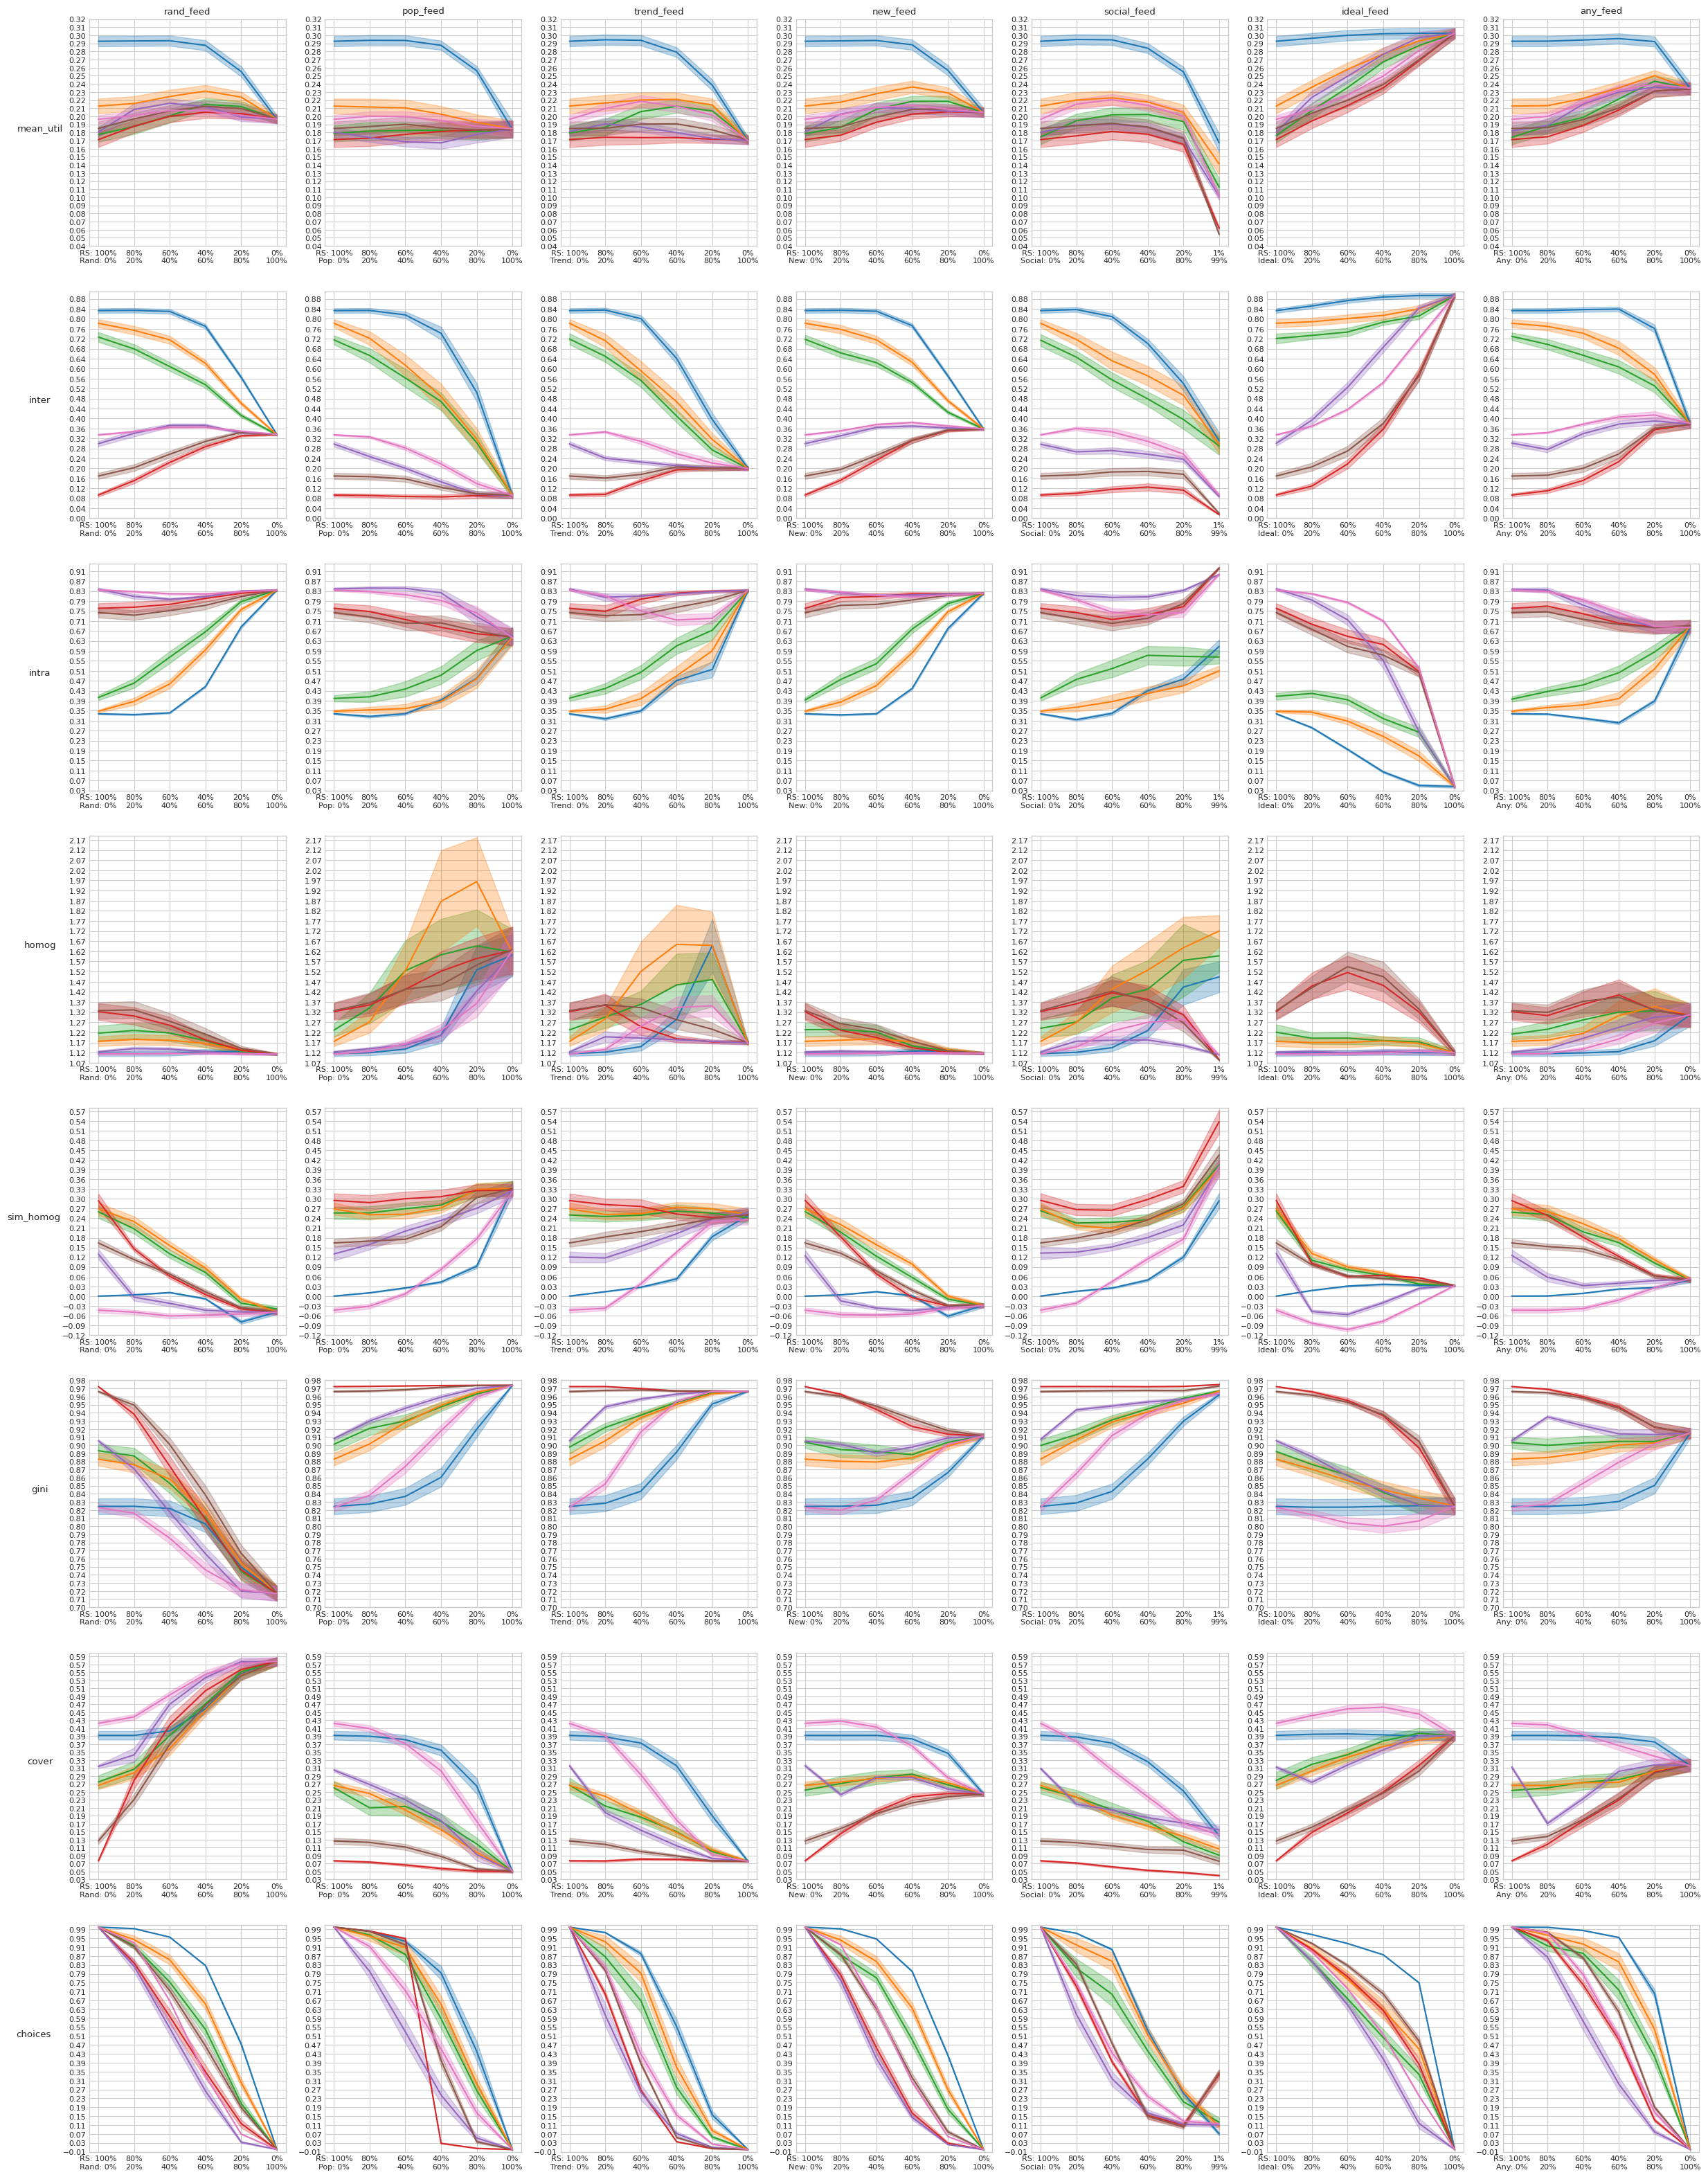

In [29]:
plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(8, 7, figsize=(30, 40))  # 8 rows, 7 columns
fig.subplots_adjust(hspace=0.2, wspace=0.2)
#fig.suptitle('Overall metrics performance of RSs vs Feeds', fontsize=10)
row=-1
for metric_name, v in metrics.items():
    row+=1
    col=-1
    upper_ylim = -10.0
    lower_ylim = 10.0
    for feed in v.keys():
        col+=1
        for mo in v[feed].keys():
            x_axis_labels = all_results_to_readable[feed]
            x_axis = [x_axis_labels[r] for r in list(v[feed][mo].keys())]
            y_axis = np.array(list(v[feed][mo].values()))[:,:,-1]
            values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
            ax = axes[row, col]
            ax.plot(x_axis, values, label=model_to_readable[mo], color=rs_colors[mo])

            std = y_axis.std(axis=1)
            mtus = np.arange(len(std))
            low = values - mult_sd * std
            high = values + mult_sd * std
            low = gaussian_filter1d(low, sigma=plotting_sigma)
            high = gaussian_filter1d(high, sigma=plotting_sigma)
            ax.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)

            upper_ylim = max(high.max(), upper_ylim)
            lower_ylim = min(low.min(), lower_ylim)
    col=-1
    upper_ylim = np.round(upper_ylim, 2) + 0.01
    lower_ylim = np.round(lower_ylim, 2) - 0.01
    for feed in v.keys():
        col+=1
        ax = axes[row, col]
        ax.set_ylim((lower_ylim, upper_ylim))
        ax.set_yticks(np.arange(lower_ylim, upper_ylim, np.round((upper_ylim-lower_ylim)/24, 2)))

for ax, col in zip(axes[0], feed_names):
    ax.set_title(col)
for ax, row in zip(axes[:,0], metrics.keys()):
    ax.set_ylabel(row, rotation=0, size='large', labelpad=30)
plt.show()